In [17]:
import logging

import tsplib95

from TP.core.logging.observer import BestFitnessLogger
from TP.core.logging.progress import EAProgressLogger
from TP.core.selection.parents.operators import TournamentStrategy
from TP.core.selection.survivors.operators import ElitismGenerational
from TP.problems.tsp.interface import TSPOrchestrator
from TP.problems.tsp.variation.mutation import CrossAwareRSM

logging.basicConfig(level=logging.INFO)


problem_instance = tsplib95.load('data/att48.tsp')

pop_size = 50
tournament_size = 3

data_logger = BestFitnessLogger()
process_logger = EAProgressLogger()
parent_selector = TournamentStrategy(tournament_size=tournament_size)
survivor_selector = ElitismGenerational(elite_pop_pct=0.05)
mutation_operator = CrossAwareRSM(problem_instance=problem_instance)


orchestrator = TSPOrchestrator(
    problem_instance=problem_instance,
    survivor_selector=survivor_selector,
    mutation_operator=mutation_operator,
    pop_size=pop_size,
    parent_selector=parent_selector,
    max_generations=1000,
    observers=[data_logger],
    loggers=[process_logger],
    p_c=0.6,
    p_m=0.5,
)
out = orchestrator.run()


INFO:TP.core.logging.progress:EA started | population_size=50
INFO:TP.core.logging.progress:Generation 250 | best=0.00009 | mean=0.00009
INFO:TP.core.logging.progress:Generation 500 | best=0.00009 | mean=0.00009
INFO:TP.core.logging.progress:Generation 750 | best=0.00009 | mean=0.00009
INFO:TP.core.logging.progress:Generation 1000 | best=0.00009 | mean=0.00009
INFO:TP.core.logging.progress:EA finished | generations=1000 | best_fitness=0.00009 | feasible=False


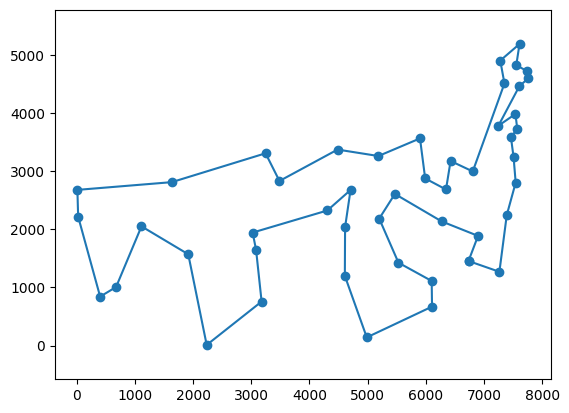

In [18]:
import matplotlib.pyplot as plt

tour = out.decode()

coords = problem_instance.node_coords
x = [coords[n][0] for n in tour]
y = [coords[n][1] for n in tour]

plt.plot(x, y, '-o')
plt.axis('equal')
plt.show()


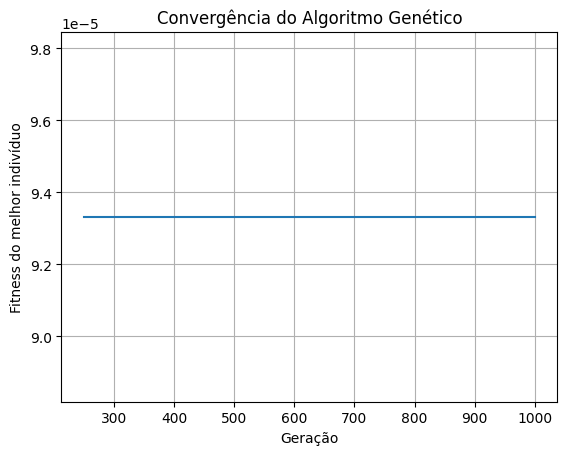

In [19]:
import matplotlib.pyplot as plt

plt.plot(data_logger.generations, data_logger.best_fitness)
plt.xlabel('Geração')
plt.ylabel('Fitness do melhor indivíduo')
plt.title('Convergência do Algoritmo Genético')
plt.grid(True)
plt.show()